# Import Libraries

In [2]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import shap
from datetime import datetime
from datetime import datetime
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import root_mean_squared_error, mean_absolute_error
from sklearn.linear_model import Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor, Pool

# Checking memory 

In [3]:
import psutil

mem = psutil.virtual_memory()
print(f"Использовано: {mem.used / 1024**3:.2f} GB / {mem.total / 1024**3:.2f} GB")


Использовано: 10.24 GB / 15.40 GB


In [4]:
import os
print(f"{os.path.getsize('../data/features.parquet') / 1024**2:.2f} MB")

50.91 MB


# Loading data

In [5]:
df = pd.read_parquet('../data/features.parquet')
test = pd.read_csv('../datasets/raw/test.csv')

# Start modeling

In [6]:
df.columns

Index(['shop_id', 'item_id', 'date_block_num', 'item_cnt_month', 'item_price',
       'item_name', 'item_category_id', 'item_category_name', 'shop_name',
       'city', 'type_of_shop', 'season', 'month_sin', 'month_cos',
       'item_cnt_month_lag_1', 'item_cnt_month_lag_2', 'item_cnt_month_lag_3',
       'item_cnt_month_lag_12', 'item_price_lag_1', 'rolling_median_3',
       'rolling_median_6', 'item_avg_sales_month_lag1', 'shop_item_avg_lag1',
       'log_item_cnt_month_lag_1', 'price_change', 'price_increasing',
       'item_min_price', 'item_max_price', 'price_range'],
      dtype='object')

# Baseline

## split on train and test

In [7]:
last_month = df['date_block_num'].max()
test_df = df[df['date_block_num'] == last_month]
train_df = df[df['date_block_num'] < last_month]

## drop target

In [8]:
X_test = test_df.drop(columns=['item_cnt_month'])
y_test = test_df['item_cnt_month']

## Fill with mean sale

In [9]:
mean_sales = train_df.groupby(['shop_id', 'item_id'])['item_cnt_month'].mean().reset_index()
mean_sales.rename(columns={'item_cnt_month': 'pred_mean'}, inplace=True)

test_mean_model = test_df.merge(mean_sales, on=['shop_id', 'item_id'], how='left')
test_mean_model['pred_mean'] = test_mean_model['pred_mean'].fillna(0)
y_pred_mean = test_mean_model['pred_mean']

## Fill with last sale

In [10]:
prev_month = last_month - 1
last_month_sales = train_df[train_df['date_block_num'] == prev_month]

lag_1 = last_month_sales[['shop_id', 'item_id', 'item_cnt_month']]
lag_1.rename(columns={'item_cnt_month': 'pred_lag1'}, inplace=True)

test_lag1_model = test_df.merge(lag_1, on=['shop_id', 'item_id'], how='left')
test_lag1_model['pred_lag1'] = test_lag1_model['pred_lag1'].fillna(0)
y_pred_lag1 = test_lag1_model['pred_lag1']

C:\Users\SUPER\AppData\Local\Temp\ipykernel_24992\1702120233.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lag_1.rename(columns={'item_cnt_month': 'pred_lag1'}, inplace=True)


In [11]:
label_encoders = {}
for col in df.select_dtypes(include='object'):
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

In [12]:

def print_metrics(y_true, y_pred, label):
    rmse = np.sqrt(root_mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    print(f"{label} — RMSE: {rmse:}, MAE: {mae:}")

y_true = y_test
print_metrics(y_true, y_pred_mean, "Средние продажи")
print_metrics(y_true, y_pred_lag1, "Продажи за прошлый месяц")

Средние продажи — RMSE: 1.1106966733932495, MAE: 0.448342889547348
Продажи за прошлый месяц — RMSE: 1.0784097909927368, MAE: 0.1855117231607437


## Advanced modeling

In [13]:
def prepare_features(df):
    features = [
        'shop_id','item_id','date_block_num','item_price',
        'item_category_id','season','month_sin','month_cos',
        'item_cnt_month_lag_1','item_cnt_month_lag_2','item_cnt_month_lag_3',
        'item_cnt_month_lag_12','item_price_lag_1','rolling_median_3',
        'rolling_median_6','item_avg_sales_month_lag1','shop_item_avg_lag1',
        'log_item_cnt_month_lag_1','price_change','price_increasing',
        'item_min_price','item_max_price','price_range'
    ]
    X = df[features]
    y = df['item_cnt_month']
    return X, y

X_train, y_train = prepare_features(train_df)
X_val, y_val = prepare_features(test_df)


## create grids

In [14]:
grids = {
    'DecisionTree': {
        'model': DecisionTreeRegressor(random_state=42),
        'params': {'max_depth': [5, 10], 'min_samples_leaf': [5, 10]}
    },
    'Ridge': {
        'model': Ridge(random_state=42),
        'params': {'alpha': [1.0, 10.0]}
    },
    'Lasso': {
        'model': Lasso(random_state=42),
        'params': {'alpha': [0.1, 1.0]}
    },
    'XGBoost': {
        'model': XGBRegressor(random_state=42, objective='reg:squarederror'),
        'params': {
            'n_estimators': [100, 200],
            'max_depth': [3, 6],
            'learning_rate': [0.1, 0.3]
        }
    }
}


## metrics

In [15]:
results = []
for name,cfg in grids.items():
    print(f"Tuning {name}...")
    gs = GridSearchCV(cfg['model'],cfg['params'],cv=3,
                      scoring='neg_mean_squared_error',n_jobs=1)
    gs.fit(X_train,y_train)
    best = gs.best_estimator_
    y_pred = best.predict(X_val)
    rmse = np.sqrt(root_mean_squared_error(y_val,y_pred))
    mae = mean_absolute_error(y_val,y_pred)
    results.append((name,rmse,mae,gs.best_params_, gs.refit_time_))
    print(f"{name} — RMSE: {rmse:}, MAE: {mae:}, Params: {gs.best_params_}")


Tuning DecisionTree...


ValueError: 
All the 12 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
4 fits failed with the following error:
Traceback (most recent call last):
  File "e:\AnacondaML\Lib\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "e:\AnacondaML\Lib\site-packages\sklearn\base.py", line 1473, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "e:\AnacondaML\Lib\site-packages\sklearn\tree\_classes.py", line 1377, in fit
    super()._fit(
  File "e:\AnacondaML\Lib\site-packages\sklearn\tree\_classes.py", line 252, in _fit
    X, y = self._validate_data(
           ^^^^^^^^^^^^^^^^^^^^
  File "e:\AnacondaML\Lib\site-packages\sklearn\base.py",

In [1]:
res_df = pd.DataFrame(results, columns=['Model','RMSE','MAE','Best_Params','Refit_Time'])
res_df

NameError: name 'pd' is not defined

In [92]:

cat_features = X.select_dtypes(include='object').columns.tolist()


In [94]:

# Pooл данных CatBoost
train_pool = Pool(X_train, y_train, cat_features=cat_features)
valid_pool = Pool(X_valid, y_valid, cat_features=cat_features)


In [95]:

# Модель регрессии
model = CatBoostRegressor(
    task_type="GPU",
    iterations=500,
    learning_rate=0.1,
    depth=6,
    eval_metric='RMSE',
    verbose=50
)


In [96]:

# Обучение
model.fit(train_pool, eval_set=valid_pool, early_stopping_rounds=50)


0:	learn: 1.7374259	test: 1.7195923	best: 1.7195923 (0)	total: 539ms	remaining: 4m 29s
50:	learn: 1.0302543	test: 1.0385594	best: 1.0385594 (50)	total: 20.2s	remaining: 2m 57s
100:	learn: 0.9765206	test: 0.9850137	best: 0.9850137 (100)	total: 40.7s	remaining: 2m 40s
150:	learn: 0.9470214	test: 0.9570545	best: 0.9570545 (150)	total: 1m 1s	remaining: 2m 22s
200:	learn: 0.9245913	test: 0.9372116	best: 0.9372116 (200)	total: 1m 22s	remaining: 2m 3s
250:	learn: 0.9066608	test: 0.9206593	best: 0.9206593 (250)	total: 1m 44s	remaining: 1m 43s
300:	learn: 0.8938153	test: 0.9090163	best: 0.9090163 (300)	total: 2m 6s	remaining: 1m 23s
350:	learn: 0.8827196	test: 0.8999178	best: 0.8999178 (350)	total: 2m 28s	remaining: 1m 3s
400:	learn: 0.8721434	test: 0.8902998	best: 0.8902845 (399)	total: 2m 50s	remaining: 42s
450:	learn: 0.8596289	test: 0.8797123	best: 0.8797123 (450)	total: 3m 11s	remaining: 20.8s
499:	learn: 0.8507653	test: 0.8730015	best: 0.8730015 (499)	total: 3m 32s	remaining: 0us
bestTest

In [99]:

y_pred = model.predict(X_valid)
y_pred


array([-0.00223697,  0.00815736,  1.14551074, ...,  0.00409646,
        1.38856298, -0.00867907])

In [100]:
rmse = np.sqrt(mean_squared_error(y_valid, y_pred))
print(f"RMSE: {rmse:.4f}")

RMSE: 0.8730


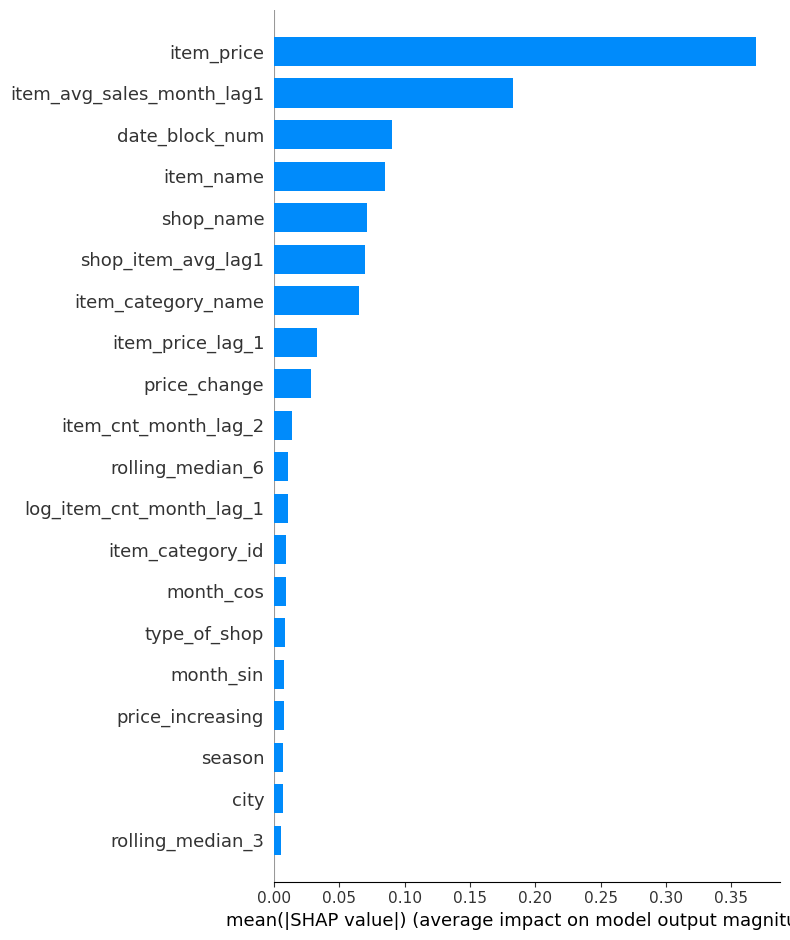

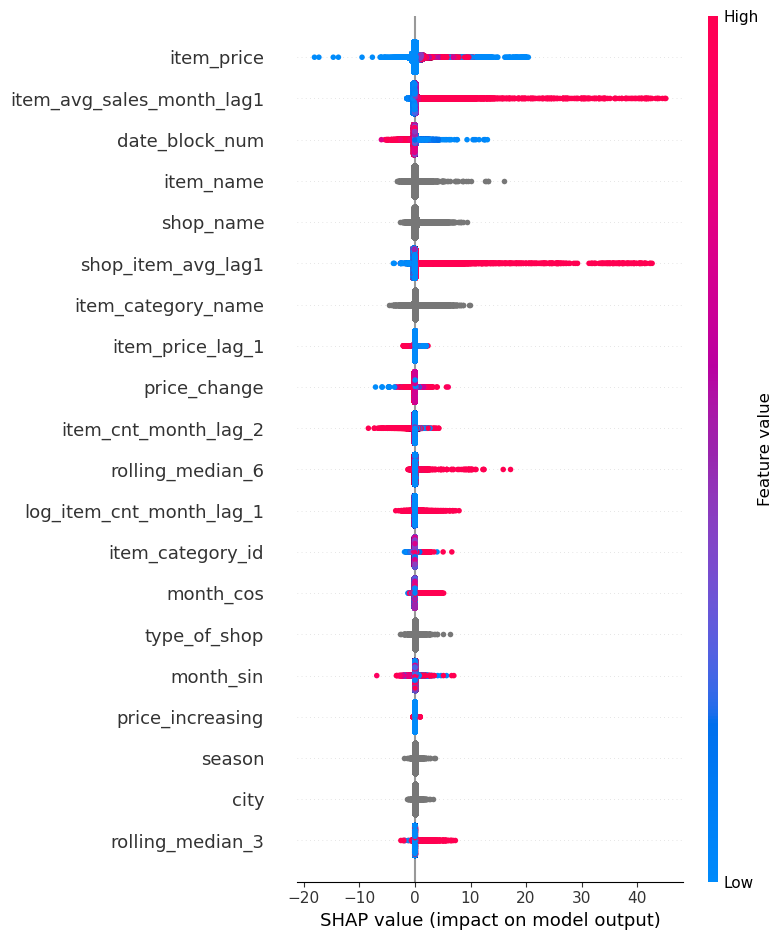

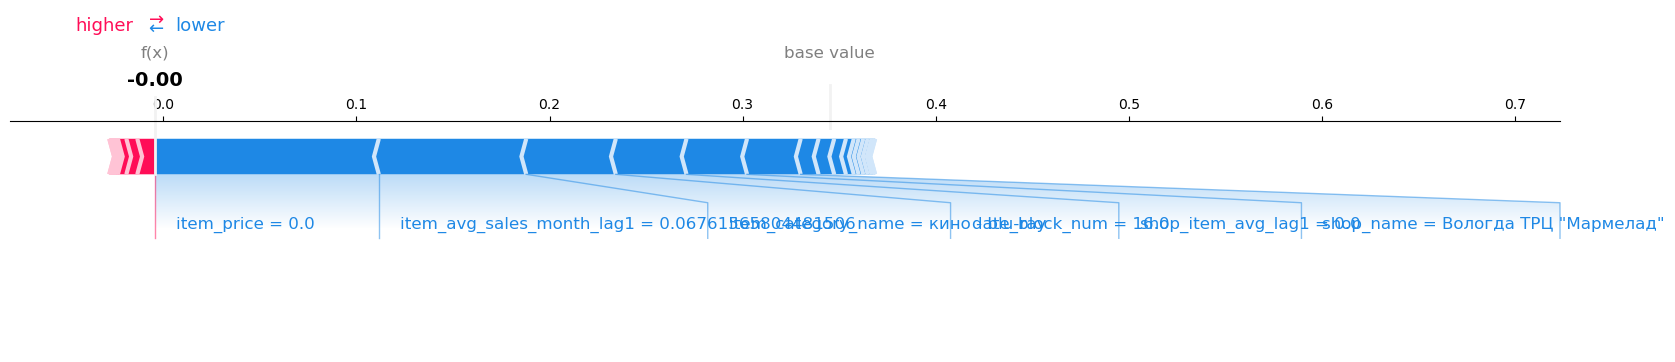

In [29]:


# Создаем explainer для CatBoost
explainer = shap.TreeExplainer(model)

# Вычисляем shap-значения на валидации
shap_values = explainer.shap_values(X_valid)

# Глобальный обзор важности
shap.summary_plot(shap_values, X_valid, plot_type="bar")

# Детальный глобальный обзор
shap.summary_plot(shap_values, X_valid)

# Локальное объяснение — например, для 1-го примера
shap.force_plot(explainer.expected_value, shap_values[0,:], X_valid.iloc[0,:], matplotlib=True)


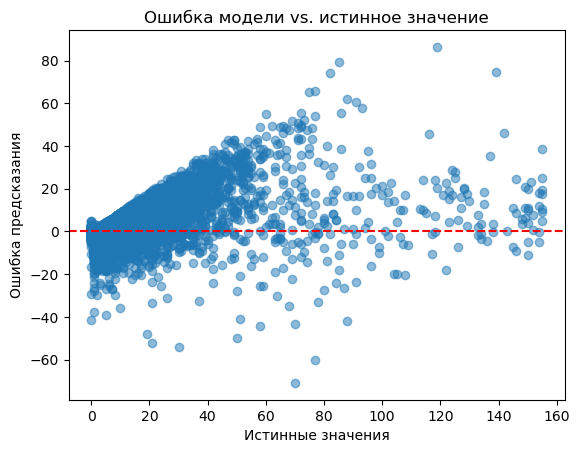

Примеры с большими ошибками:
         shop_id  item_id  date_block_num   item_price  \
8965049       54    20949              24     5.000000   
3667390       25     7096               8   798.062805   
3845308       25    16790              19  2178.885010   
8989878       55      805              11   100.000000   
5356730       31    12090              24   399.000000   
6758425       42    20949              13     5.000000   
8999211       55     3339              20  1499.000000   
2635952       18    20949               4     5.000000   
8993585       55     1875              26  1999.000000   
9756271       58    20949               5     5.000000   

                                                 item_name  item_category_id  \
8965049  фирменный пакет майка 1с интерес белый (34*42)...                71   
3667390      total war: rome 2 [pc, jewel, русская версия]                30   
3845308  одни из нас. обновленная версия [ps4, русская ...                20   
8989878  1с:

In [30]:
import matplotlib.pyplot as plt
import numpy as np

y_pred = model.predict(X_valid)
errors = y_valid - y_pred

# Ошибка vs. истинное значение
plt.scatter(y_valid, errors, alpha=0.5)
plt.xlabel('Истинные значения')
plt.ylabel('Ошибка предсказания')
plt.title('Ошибка модели vs. истинное значение')
plt.axhline(0, color='red', linestyle='--')
plt.show()

# Анализ больших ошибок
large_errors_idx = np.argsort(np.abs(errors))[-10:]
print("Примеры с большими ошибками:")
print(X_valid.iloc[large_errors_idx])
print("Ошибка:")
print(errors.iloc[large_errors_idx])


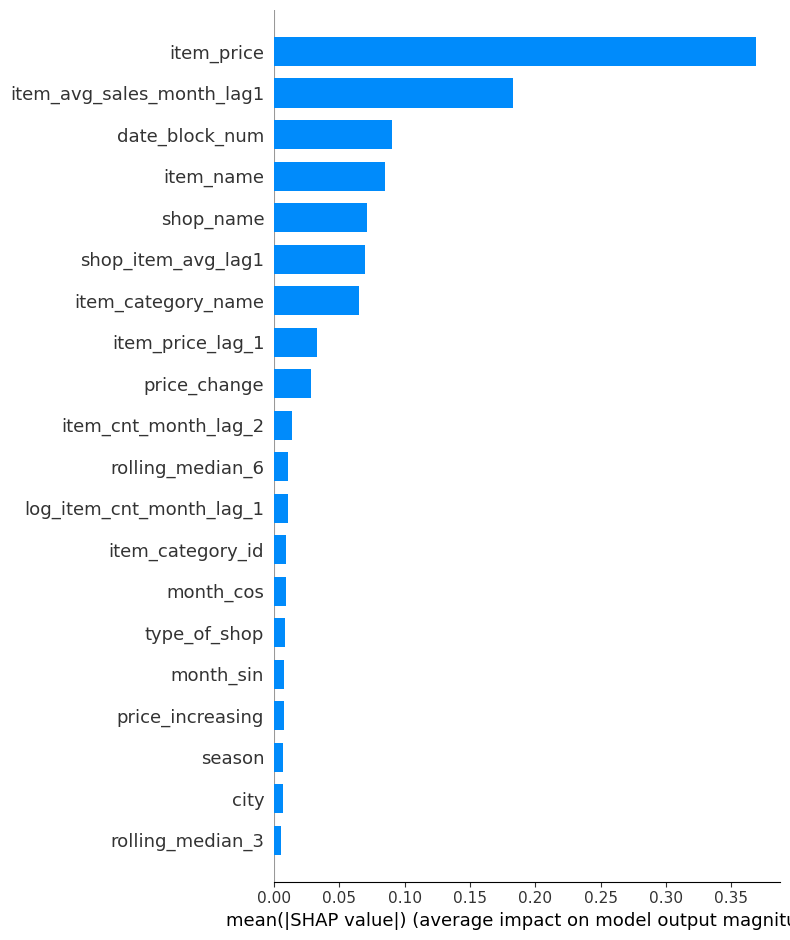

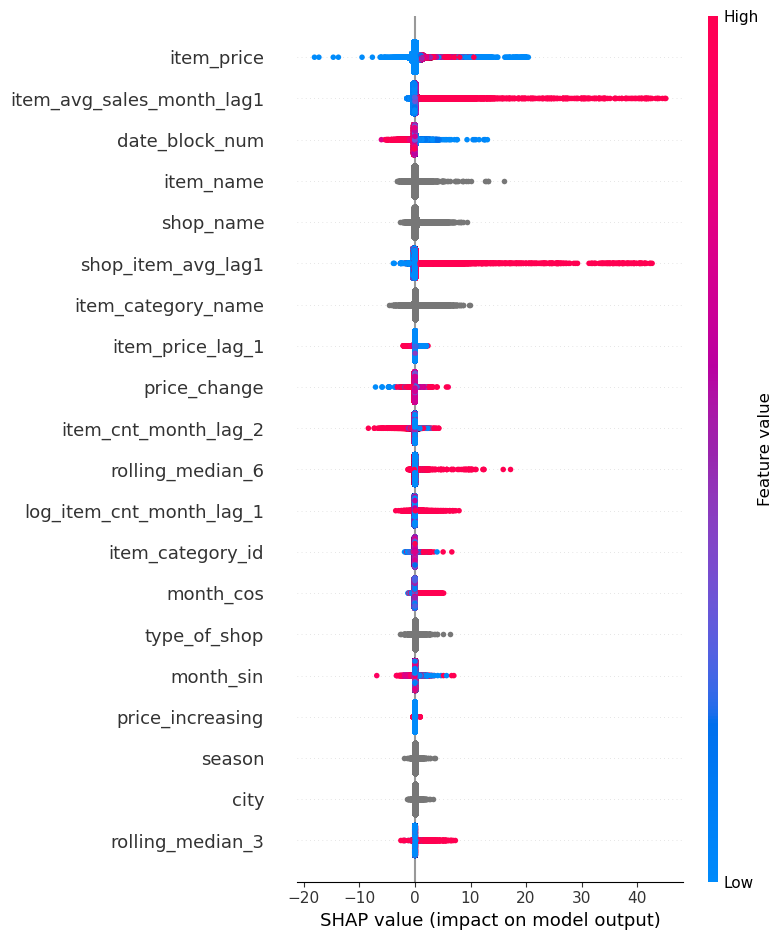

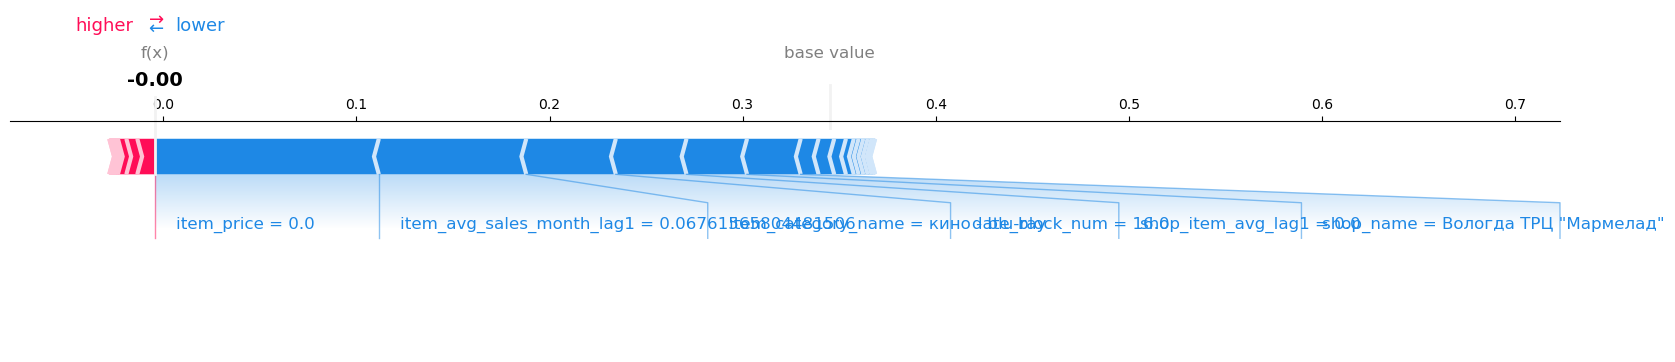

In [32]:
import shap

# Создаем explainer для CatBoost
explainer = shap.TreeExplainer(model)

# Вычисляем shap-значения на валидации
shap_values = explainer.shap_values(X_valid)

# Глобальный обзор важности
shap.summary_plot(shap_values, X_valid, plot_type="bar")

# Детальный глобальный обзор
shap.summary_plot(shap_values, X_valid)

# Локальное объяснение — например, для 1-го примера
shap.force_plot(explainer.expected_value, shap_values[0,:], X_valid.iloc[0,:], matplotlib=True)
